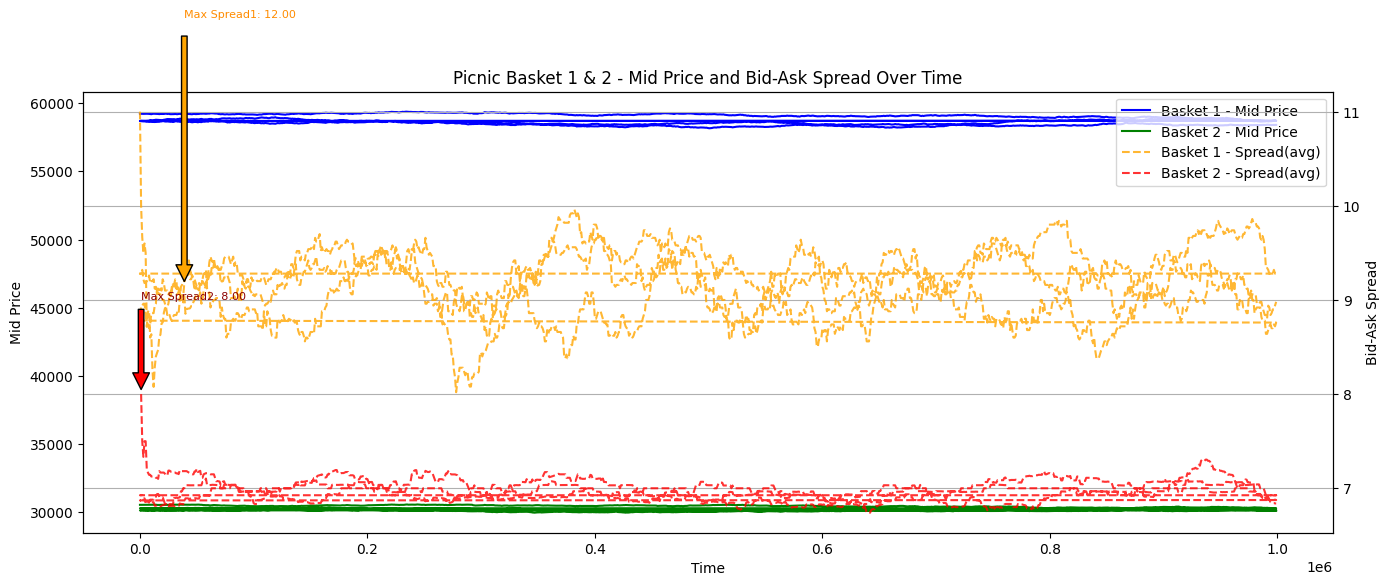

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

#file extrated
extract_path = r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle"
price_paths = [
    os.path.join(extract_path, r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle\prices_round_3_day_0.csv"),
    os.path.join(extract_path, r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle\prices_round_3_day_1.csv"),
    os.path.join(extract_path, r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle\prices_round_3_day_2.csv") 
]

#merged all 3 days of price data
df = pd.concat([pd.read_csv(path, delimiter=';') for path in price_paths], ignore_index=True)


#bid ask spread
df['bid_ask_spread1'] = df['ask_price_1'] - df['bid_price_1']
df['bid_ask_spread2'] = df['ask_price_2'] - df['bid_price_2']

df['mid_price'] = pd.to_numeric(df['mid_price'], errors='coerce')
df['bid_volume_1'] = pd.to_numeric(df['bid_volume_1'], errors='coerce')
df['ask_volume_1'] = pd.to_numeric(df['ask_volume_1'], errors='coerce')

df_pb1 = df[df['product'] == 'PICNIC_BASKET1']
df_pb2 = df[df['product'] == 'PICNIC_BASKET2']


df_pb1_sampled = df_pb1.iloc[::10].copy()
df_pb2_sampled = df_pb2.iloc[::10].copy()

df_pb1_sampled['spread_avg'] = df_pb1_sampled['bid_ask_spread1'].rolling(window=50, min_periods=1).mean()
df_pb2_sampled['spread_avg'] = df_pb2_sampled['bid_ask_spread2'].rolling(window=50, min_periods=1).mean()


# Plot with secondary y-axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Mid Prices (left y-axis)
ax1.plot(df_pb1_sampled['timestamp'], df_pb1_sampled['mid_price'], label='Basket 1 - Mid Price', color='blue',)
ax1.plot(df_pb2_sampled['timestamp'], df_pb2_sampled['mid_price'], label='Basket 2 - Mid Price', color='green')
ax1.set_ylabel("Mid Price")
ax1.set_xlabel("Time")

# Bid-Ask Spreads (right y-axis)
ax2 = ax1.twinx()
ax2.plot(df_pb1_sampled['timestamp'], df_pb1_sampled['spread_avg'], label='Basket 1 - Spread(avg)', color='orange', linestyle='--', alpha = 0.8)
ax2.plot(df_pb2_sampled['timestamp'], df_pb2_sampled['spread_avg'], label='Basket 2 - Spread(avg)', color='red', linestyle='--', alpha = 0.8)
ax2.set_ylabel("Bid-Ask Spread")


# Annotations
ax2.annotate(f'Max Spread1: {df_pb1_sampled.loc[max1_idx, "bid_ask_spread1"]:.2f}',
             xy=(df_pb1_sampled.loc[max1_idx, 'timestamp'], df_pb1_sampled.loc[max1_idx, 'spread_avg']),
             xytext=(df_pb1_sampled.loc[max1_idx, 'timestamp'], df_pb1_sampled['spread_avg'].max() + 1),
             arrowprops=dict(facecolor='orange', shrink=0.05),
             fontsize=8, color='darkorange')

ax2.annotate(f'Max Spread2: {df_pb2_sampled.loc[max2_idx, "bid_ask_spread2"]:.2f}',
             xy=(df_pb2_sampled.loc[max2_idx, 'timestamp'], df_pb2_sampled.loc[max2_idx, 'spread_avg']),
             xytext=(df_pb2_sampled.loc[max2_idx, 'timestamp'], df_pb2_sampled['spread_avg'].max() + 1),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=8, color='darkred')


# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title("Picnic Basket 1 & 2 - Mid Price and Bid-Ask Spread Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()



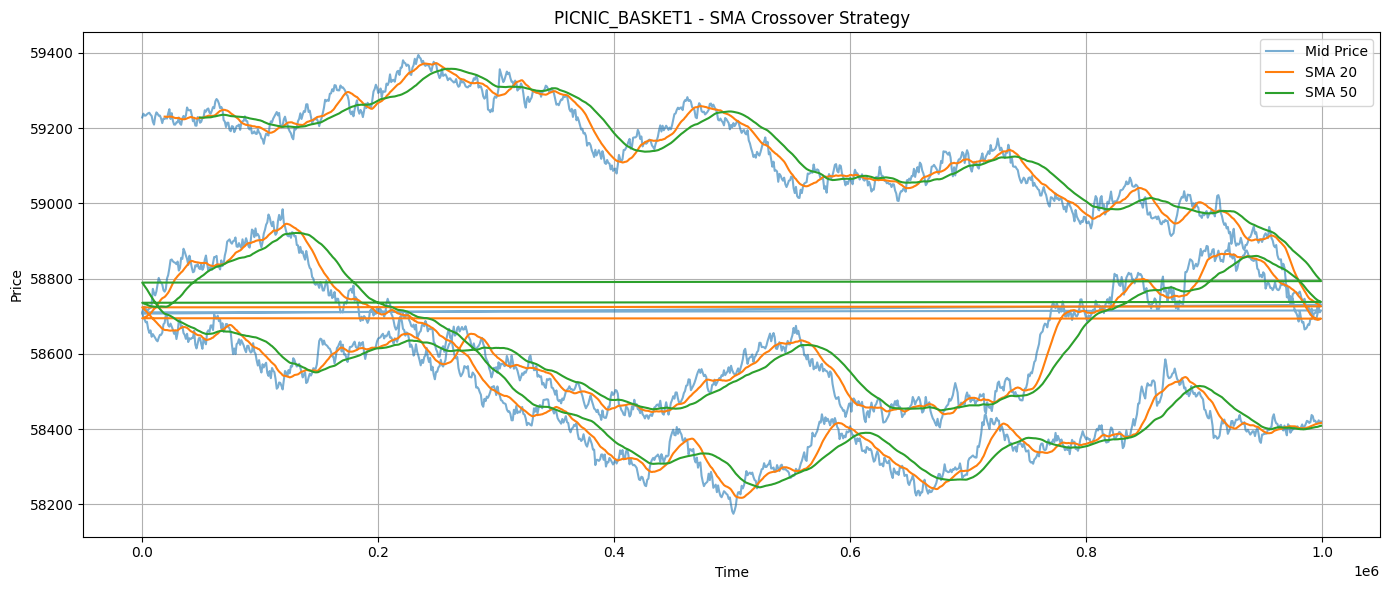

In [ ]:
#simple moving average
df_pb1 = df[df['product'] == 'PICNIC_BASKET1'].copy()
df_pb1['mid_price'] = pd.to_numeric(df_pb1['mid_price'], errors='coerce')
df_pb1 = df_pb1.dropna(subset=['mid_price'])  # Drop rows with NaN mid price

# Sample and calculate SMAs
df_pb1 = df_pb1.iloc[::10]
df_pb1['sma_20'] = df_pb1['mid_price'].rolling(window=20).mean()
df_pb1['sma_50'] = df_pb1['mid_price'].rolling(window=50).mean()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_pb1['timestamp'], df_pb1['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(df_pb1['timestamp'], df_pb1['sma_20'], label='SMA 20')
plt.plot(df_pb1['timestamp'], df_pb1['sma_50'], label='SMA 50')
plt.title("PICNIC_BASKET1 - SMA Crossover Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




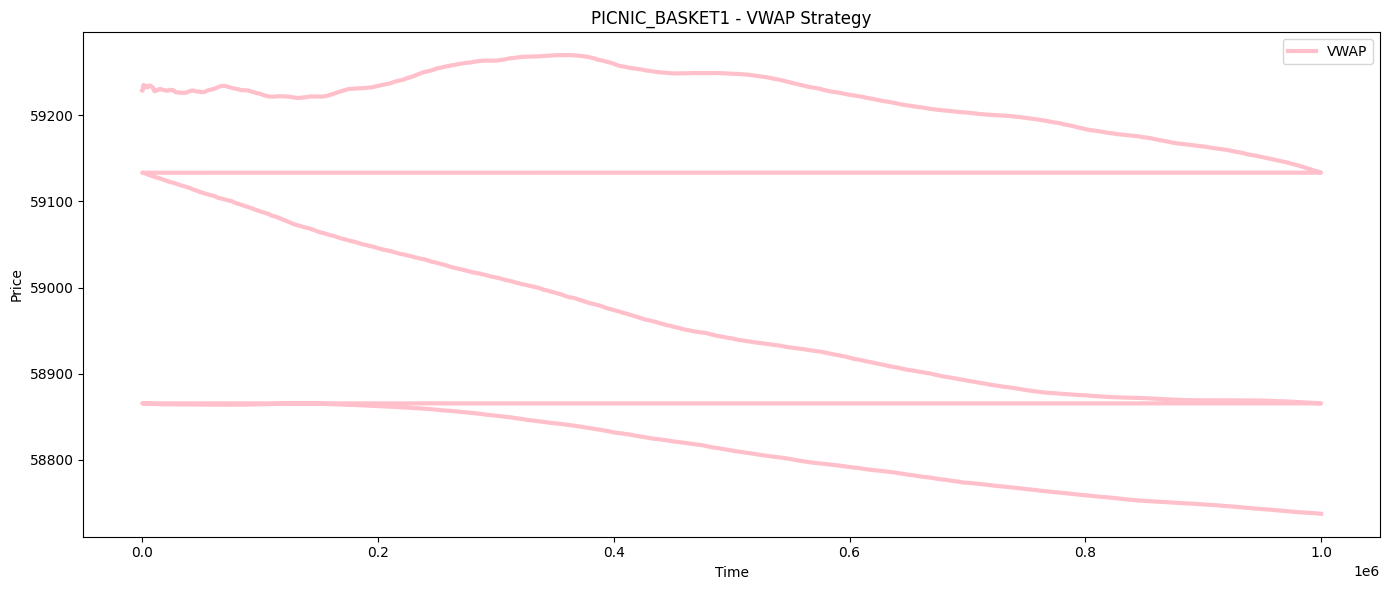

In [ ]:
#vwap strategy
df_pb1.loc[:, 'vwap_numerator'] = df_pb1['mid_price'] * (df_pb1['ask_volume_1']+ df_pb1['bid_volume_1'])
df_pb1.loc[:, 'vwap_denominator'] = df_pb1['ask_volume_1'] + df_pb1['bid_volume_1']
df_pb1.loc[:, 'vwap'] = df_pb1['vwap_numerator'].cumsum() / df_pb1['vwap_denominator'].cumsum()


#plot
plt.figure(figsize=(14, 6))
plt.plot(df_pb1['timestamp'], df_pb1['vwap'], label='VWAP', color = 'pink', linewidth = 3)
plt.title("PICNIC_BASKET1 - VWAP Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


C:\Users\AHILI\AppData\Local\Temp\ipykernel_4976\3201010457.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\AHILI\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


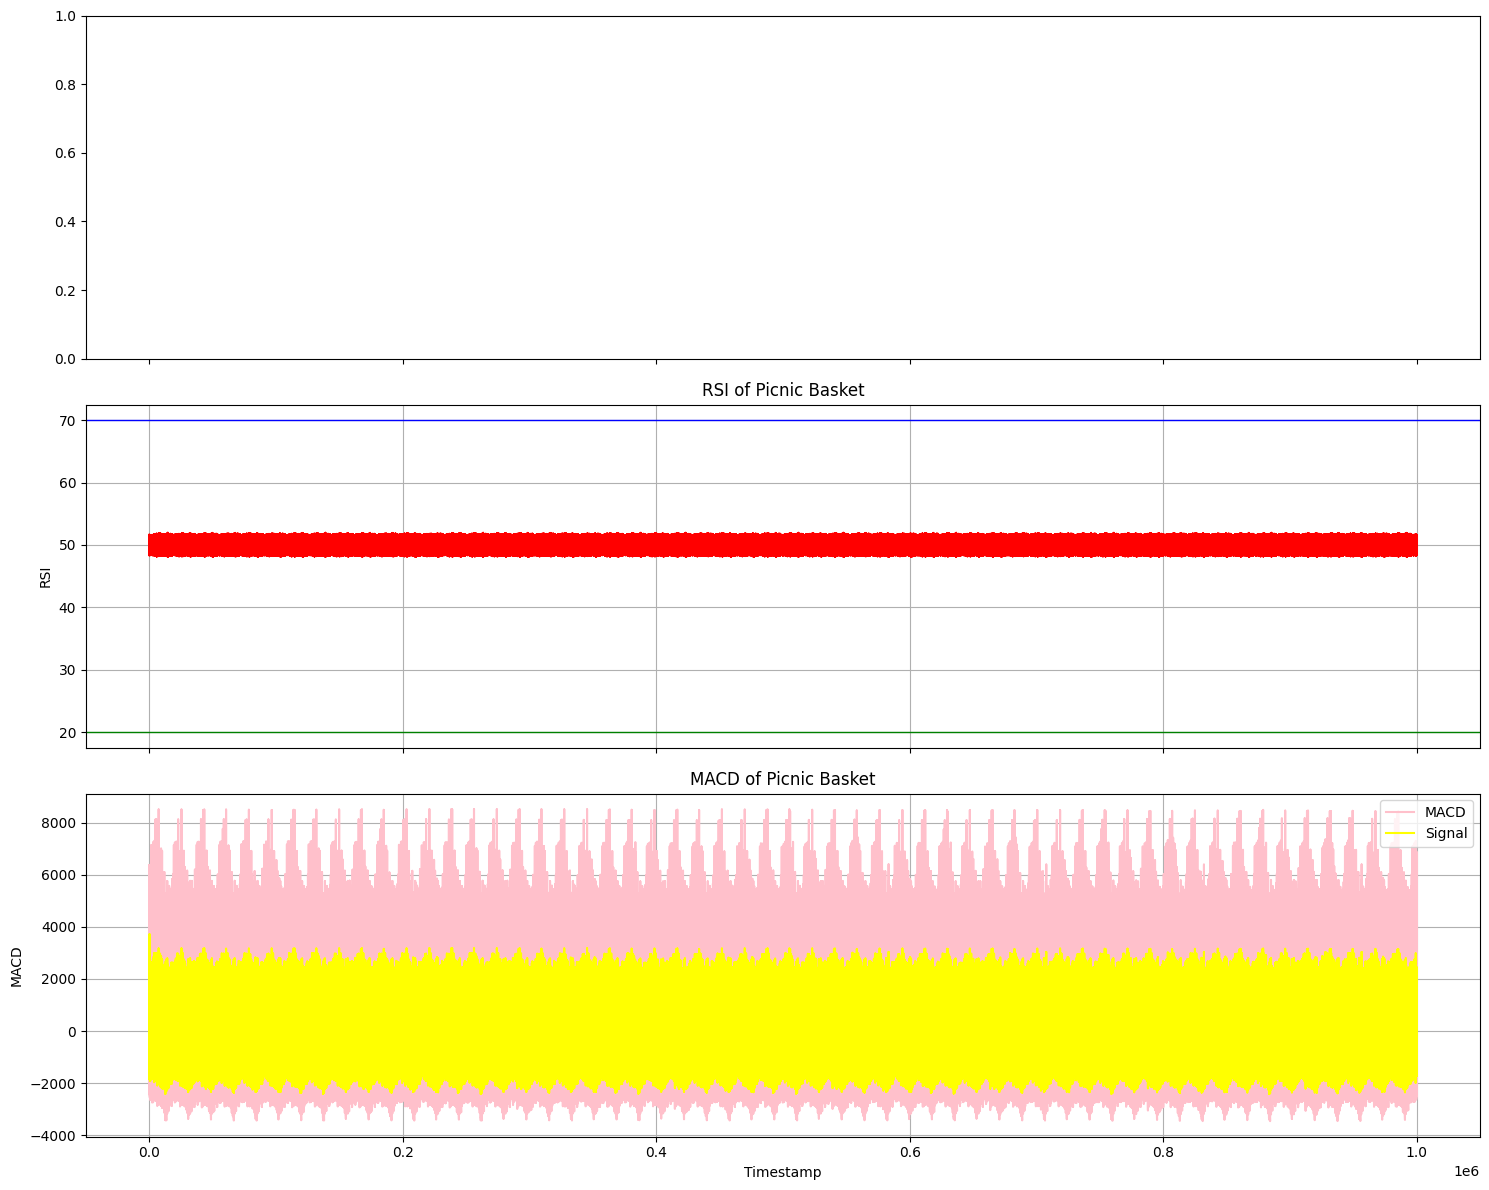

In [55]:
#rsi
window_length =  14
delta = df["mid_price"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window = window_length).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window = window_length).mean()
rsi = gain / loss
df["RSI"] = 100 - (100 / (1 + rsi))

fig, axes = plt.subplots(3, 1, figsize = (15, 12), sharex = True)
axes[1].plot(df["timestamp"], df["RSI"], label = "RSI", color = "red")
axes[1].axhline(70, color = 'blue', linestyle = 'solid', linewidth = 1)
axes[1].axhline(20, color = 'green', linestyle = 'solid', linewidth = 1)
axes[1].set_title("RSI of Picnic Basket")
axes[1].set_ylabel("RSI")
axes[1].grid(True)

#macd
exp1 = df["mid_price"].ewm(span = 12, adjust = False).mean()
exp2 = df["mid_price"].ewm(span = 26, adjust = False).mean()
df["MacD"] = exp1 - exp2
df["Signal"] = df["MacD"].ewm(span = 10, adjust = False).mean()

axes[2].plot(df["timestamp"], df["MacD"], label = "MACD", color = "pink")
axes[2].plot(df["timestamp"], df["Signal"], label = "Signal", color = "yellow")
axes[2].set_title("MACD of Picnic Basket")
axes[2].set_ylabel("MACD")
axes[2].grid(True)
axes[2].legend()
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

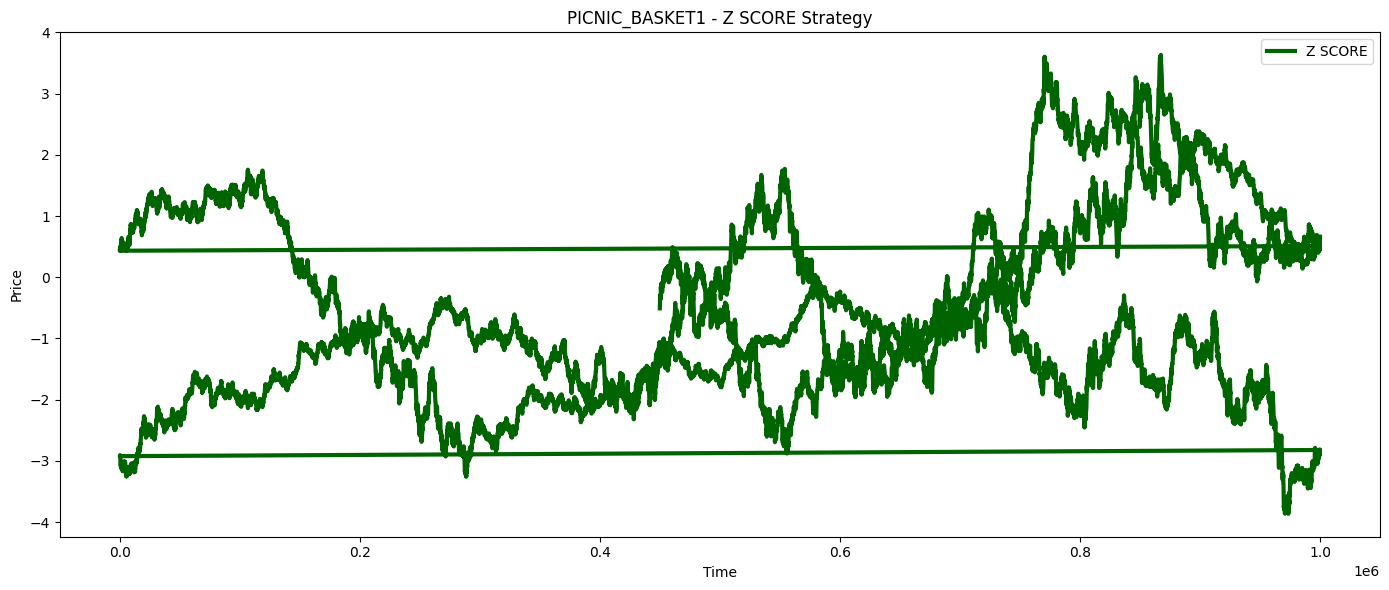

In [53]:
#zscore
window = 4500
df_pb1.loc[:, 'rolling_mean'] = df_pb1['mid_price'].rolling(window = window).mean()
df_pb1.loc[:, 'rolling_std'] = df_pb1['mid_price'].rolling(window = window).std()
df_pb1.loc[:, 'z_score'] =  (df_pb1['mid_price'] - df_pb1['rolling_mean']) / df_pb1['rolling_std']
df_pb1.loc[:, 'signal'] = df_pb1['z_score'].apply(lambda x: 'Buy' if x<-1 else 'Sell' if x>1 else 'Hold')

plt.figure(figsize=(14, 6))
plt.plot(df_pb1['timestamp'], df_pb1['z_score'], label='Z SCORE', color = 'darkgreen', linewidth = 3)
plt.title("PICNIC_BASKET1 - Z SCORE Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


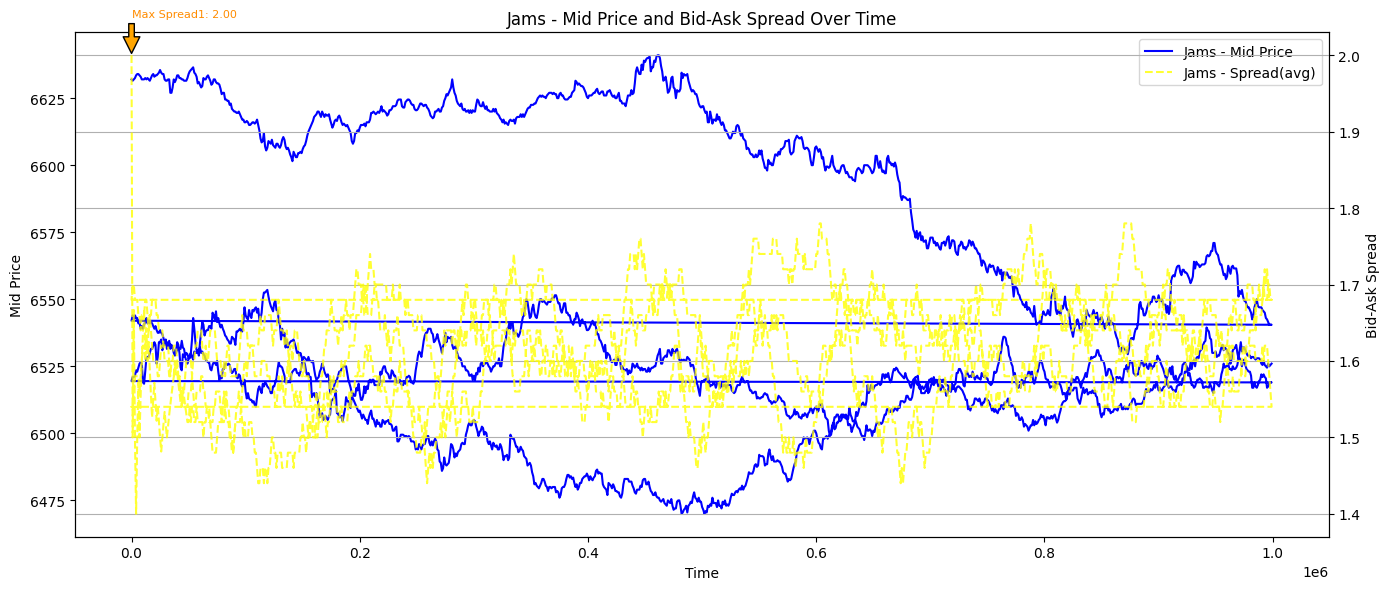

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

#file extrated
extract_path = r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle"
price_paths = [
    os.path.join(extract_path, r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle\prices_round_3_day_0.csv"),
    os.path.join(extract_path, r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle\prices_round_3_day_1.csv"),
    os.path.join(extract_path, r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle\prices_round_3_day_2.csv") 
]

#merged all 3 days of price data
df = pd.concat([pd.read_csv(path, delimiter=';') for path in price_paths], ignore_index=True)


#bid ask spread
df['bid_ask_spread1'] = df['ask_price_1'] - df['bid_price_1']
df['bid_ask_spread2'] = df['ask_price_2'] - df['bid_price_2']

df['mid_price'] = pd.to_numeric(df['mid_price'], errors='coerce')
df['bid_volume_1'] = pd.to_numeric(df['bid_volume_1'], errors='coerce')
df['ask_volume_1'] = pd.to_numeric(df['ask_volume_1'], errors='coerce')

df_jams = df[df['product'] == 'JAMS']



df_jams_sampled = df_jams.iloc[::10].copy()


df_jams_sampled['spread_avg'] = df_jams_sampled['bid_ask_spread1'].rolling(window=50, min_periods=1).mean()



# Plot with secondary y-axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Mid Prices (left y-axis)
ax1.plot(df_jams_sampled['timestamp'], df_jams_sampled['mid_price'], label='Jams - Mid Price', color='blue',)
ax1.set_ylabel("Mid Price")
ax1.set_xlabel("Time")

# Bid-Ask Spreads (right y-axis)
ax2 = ax1.twinx()
ax2.plot(df_jams_sampled['timestamp'], df_jams_sampled['spread_avg'], label='Jams - Spread(avg)', color='yellow', linestyle='--', alpha = 0.8)
ax2.set_ylabel("Bid-Ask Spread")

max1_idx = df_jams_sampled['bid_ask_spread1'].idxmax()


# Annotations
ax2.annotate(f'Max Spread1: {df_jams_sampled.loc[max1_idx, "bid_ask_spread1"]:.2f}',
             xy=(df_jams_sampled.loc[max1_idx, 'timestamp'], df_jams_sampled.loc[max1_idx, 'spread_avg']),
             xytext=(df_jams_sampled.loc[max1_idx, 'timestamp'], df_jams_sampled['spread_avg'].max() + 0.05),
             arrowprops=dict(facecolor='orange', shrink=0.05),
             fontsize=8, color='darkorange')


# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title("Jams - Mid Price and Bid-Ask Spread Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()

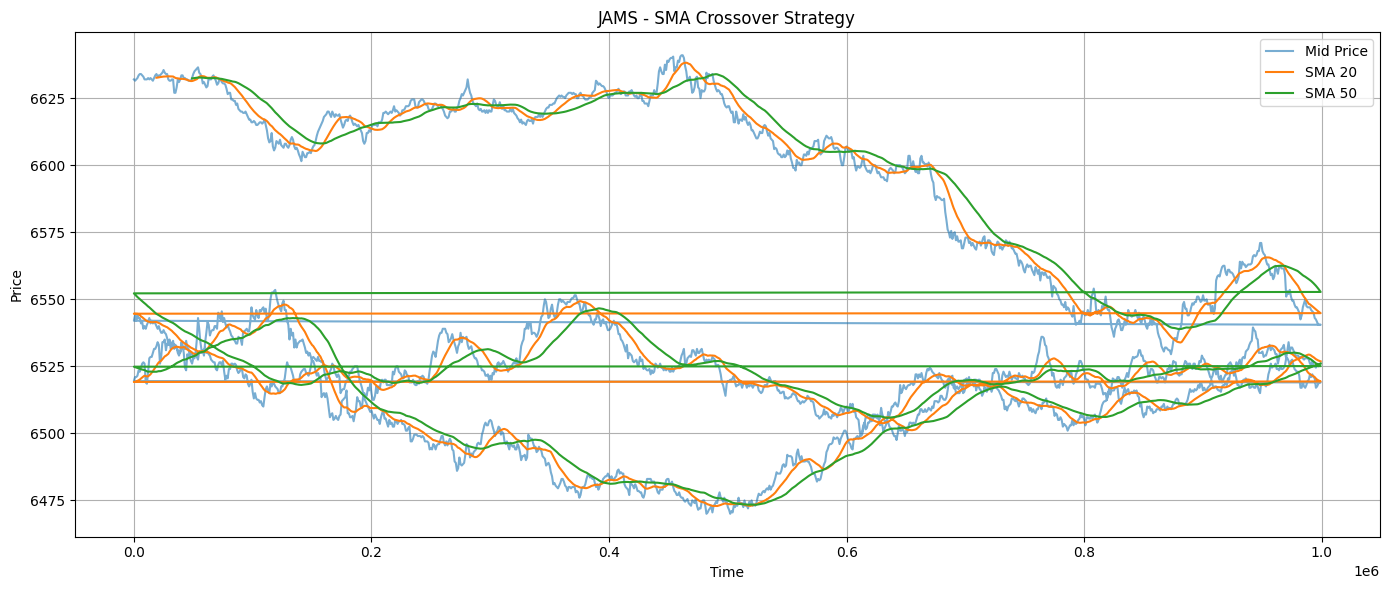

In [4]:
#simple moving average
df_jams = df[df['product'] == 'JAMS'].copy()
df_jams['mid_price'] = pd.to_numeric(df_jams['mid_price'], errors='coerce')
df_jams = df_jams.dropna(subset=['mid_price'])  # Drop rows with NaN mid price

# Sample and calculate SMAs
df_jams = df_jams.iloc[::10]
df_jams['sma_20'] = df_jams['mid_price'].rolling(window=20).mean()
df_jams['sma_50'] = df_jams['mid_price'].rolling(window=50).mean()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_jams['timestamp'], df_jams['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(df_jams['timestamp'], df_jams['sma_20'], label='SMA 20')
plt.plot(df_jams['timestamp'], df_jams['sma_50'], label='SMA 50')
plt.title("JAMS - SMA Crossover Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

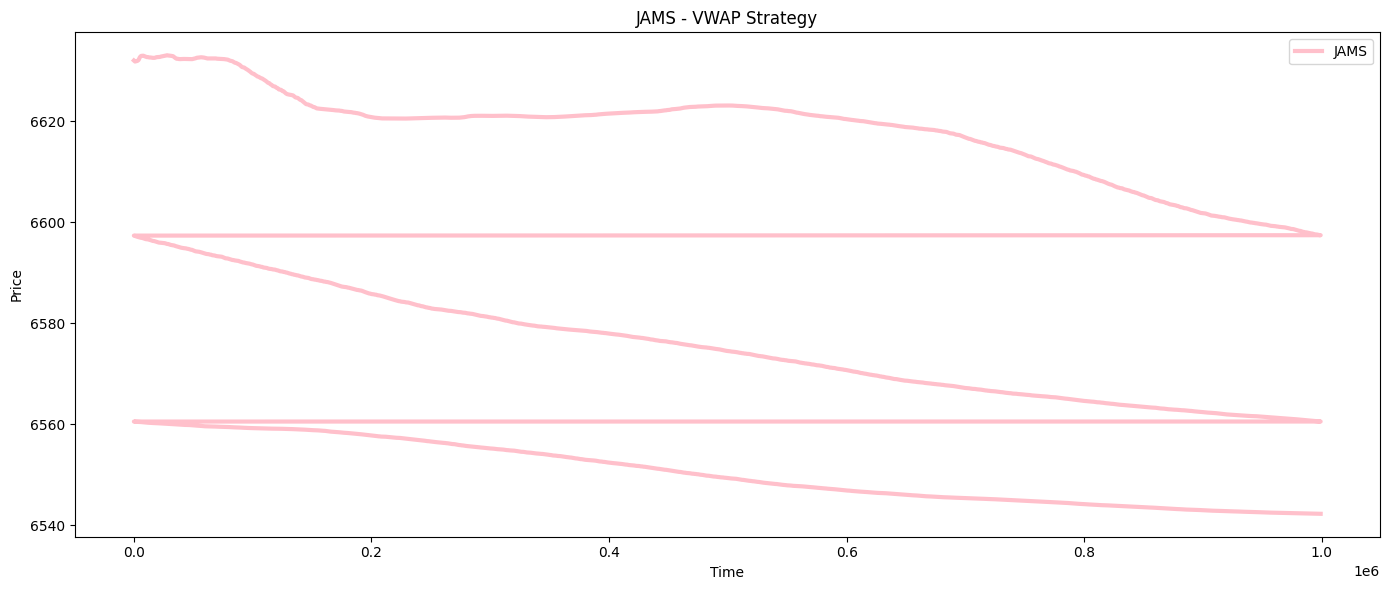

In [6]:
#vwap strategy
df_jams.loc[:, 'vwap_numerator'] = df_jams['mid_price'] * (df_jams['ask_volume_1']+ df_jams['bid_volume_1'])
df_jams.loc[:, 'vwap_denominator'] = df_jams['ask_volume_1'] + df_jams['bid_volume_1']
df_jams.loc[:, 'vwap'] = df_jams['vwap_numerator'].cumsum() / df_jams['vwap_denominator'].cumsum()


#plot
plt.figure(figsize=(14, 6))
plt.plot(df_jams['timestamp'], df_jams['vwap'], label='JAMS', color = 'pink', linewidth = 3)
plt.title("JAMS - VWAP Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

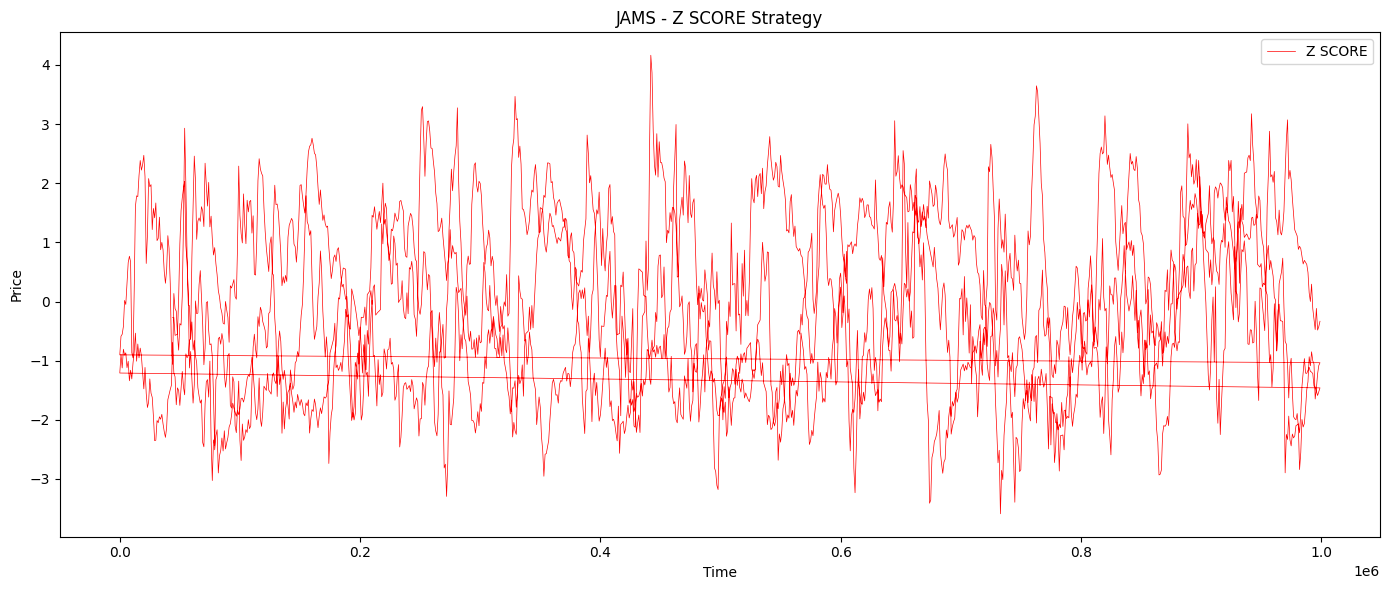

In [12]:
#zscore
window = 45
df_jams.loc[:, 'rolling_mean'] = df_jams['mid_price'].rolling(window = window).mean()
df_jams.loc[:, 'rolling_std'] = df_jams['mid_price'].rolling(window = window).std()
df_jams.loc[:, 'z_score'] =  (df_jams['mid_price'] - df_jams['rolling_mean']) / df_jams['rolling_std']
df_jams.loc[:, 'signal'] = df_jams['z_score'].apply(lambda x: 'Buy' if x<-1 else 'Sell' if x>1 else 'Hold')

plt.figure(figsize=(14, 6))
plt.plot(df_jams['timestamp'], df_jams['z_score'], label='Z SCORE', color = 'red', linewidth = 0.5)
plt.title("JAMS - Z SCORE Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


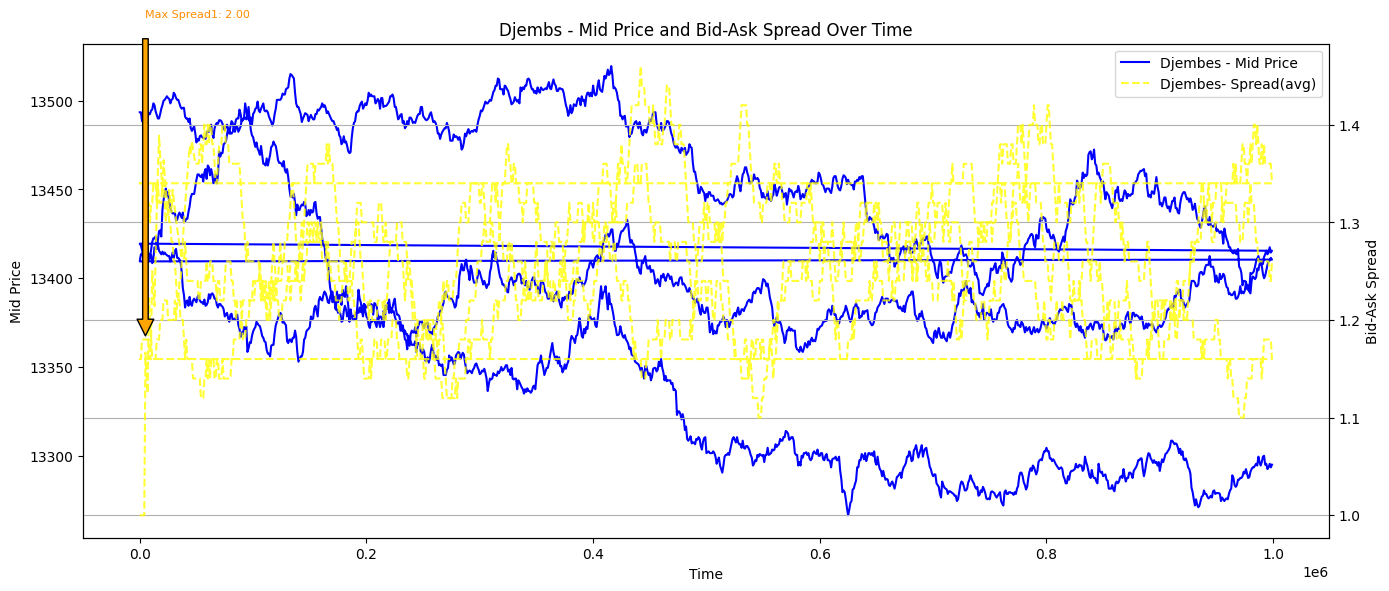

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

#file extrated
extract_path = r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle"
price_paths = [
    os.path.join(extract_path, r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle\prices_round_3_day_0.csv"),
    os.path.join(extract_path, r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle\prices_round_3_day_1.csv"),
    os.path.join(extract_path, r"C:\Users\AHILI\Downloads\round-3-island-data-bottle\round-3-island-data-bottle\prices_round_3_day_2.csv") 
]

#merged all 3 days of price data
df = pd.concat([pd.read_csv(path, delimiter=';') for path in price_paths], ignore_index=True)

                                                                                                                                      #DJEMBES
#bid ask spread
df['bid_ask_spread1'] = df['ask_price_1'] - df['bid_price_1']
df['bid_ask_spread2'] = df['ask_price_2'] - df['bid_price_2']

df['mid_price'] = pd.to_numeric(df['mid_price'], errors='coerce')
df['bid_volume_1'] = pd.to_numeric(df['bid_volume_1'], errors='coerce')
df['ask_volume_1'] = pd.to_numeric(df['ask_volume_1'], errors='coerce')

df_dj = df[df['product'] == 'DJEMBES']



df_dj_sampled = df_dj.iloc[::10].copy()


df_dj_sampled['spread_avg'] = df_dj_sampled['bid_ask_spread1'].rolling(window=50, min_periods=1).mean()



# Plot with secondary y-axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Mid Prices (left y-axis)
ax1.plot(df_dj_sampled['timestamp'], df_dj_sampled['mid_price'], label='Djembes - Mid Price', color='blue',)
ax1.set_ylabel("Mid Price")
ax1.set_xlabel("Time")

# Bid-Ask Spreads (right y-axis)
ax2 = ax1.twinx()
ax2.plot(df_dj_sampled['timestamp'], df_dj_sampled['spread_avg'], label='Djembes- Spread(avg)', color='yellow', linestyle='--', alpha = 0.8)
ax2.set_ylabel("Bid-Ask Spread")

max1_idx = df_dj_sampled['bid_ask_spread1'].idxmax()


# Annotations
ax2.annotate(f'Max Spread1: {df_dj_sampled.loc[max1_idx, "bid_ask_spread1"]:.2f}',
             xy=(df_dj_sampled.loc[max1_idx, 'timestamp'], df_dj_sampled.loc[max1_idx, 'spread_avg']),
             xytext=(df_dj_sampled.loc[max1_idx, 'timestamp'], df_dj_sampled['spread_avg'].max() + 0.05),
             arrowprops=dict(facecolor='orange', shrink=0.05),
             fontsize=8, color='darkorange')


# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title("Djembs - Mid Price and Bid-Ask Spread Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()

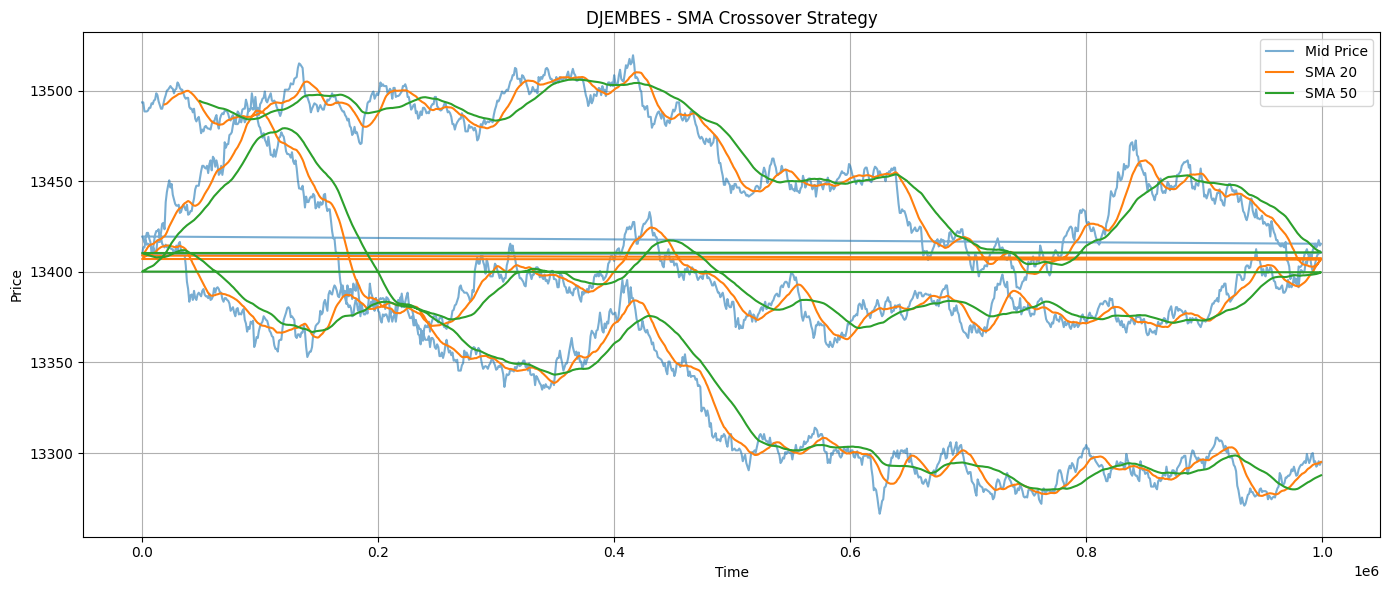

In [26]:
#simple moving average
df_dj = df[df['product'] == 'DJEMBES'].copy()
df_dj['mid_price'] = pd.to_numeric(df_dj['mid_price'], errors='coerce')
df_dj = df_dj.dropna(subset=['mid_price'])  # Drop rows with NaN mid price

# Sample and calculate SMAs
df_dj = df_dj.iloc[::10]
df_dj['sma_20'] = df_dj['mid_price'].rolling(window=20).mean()
df_dj['sma_50'] = df_dj['mid_price'].rolling(window=50).mean()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_dj['timestamp'], df_dj['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(df_dj['timestamp'], df_dj['sma_20'], label='SMA 20')
plt.plot(df_dj['timestamp'], df_dj['sma_50'], label='SMA 50')
plt.title("DJEMBES - SMA Crossover Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

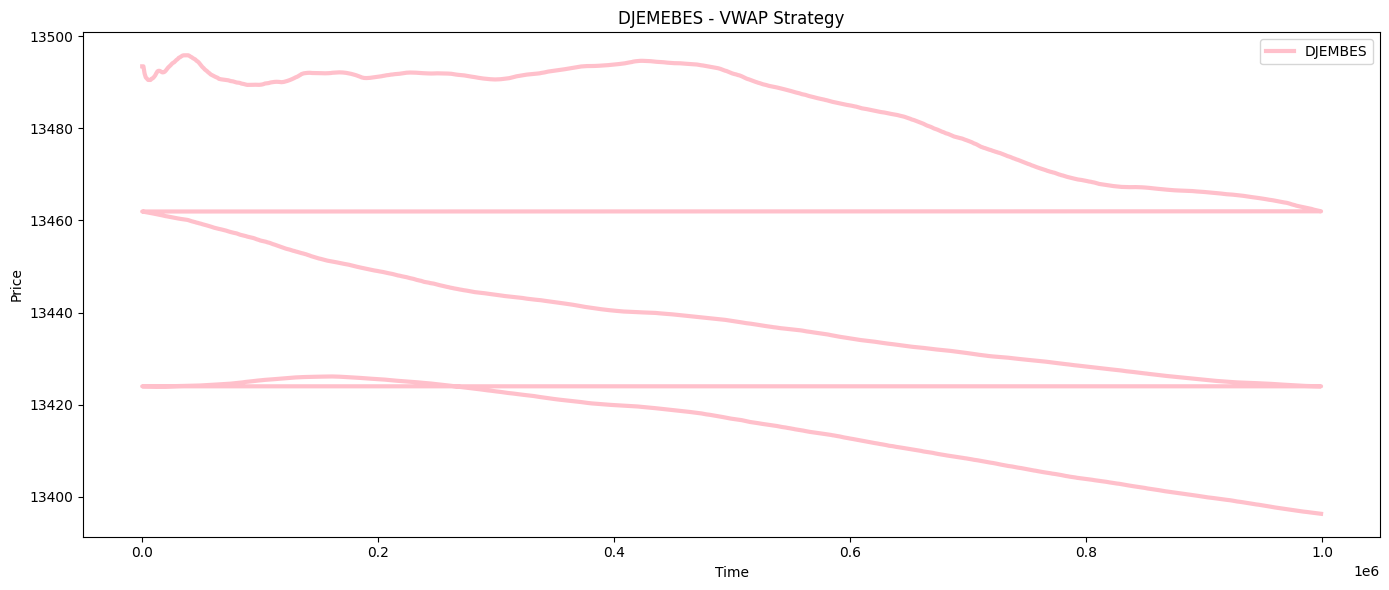

In [27]:
#vwap strategy
df_dj.loc[:, 'vwap_numerator'] = df_dj['mid_price'] * (df_dj['ask_volume_1']+ df_dj['bid_volume_1'])
df_dj.loc[:, 'vwap_denominator'] = df_dj['ask_volume_1'] + df_dj['bid_volume_1']
df_dj.loc[:, 'vwap'] = df_dj['vwap_numerator'].cumsum() / df_dj['vwap_denominator'].cumsum()


#plot
plt.figure(figsize=(14, 6))
plt.plot(df_dj['timestamp'], df_dj['vwap'], label='DJEMBES', color = 'pink', linewidth = 3)
plt.title("DJEMEBES - VWAP Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

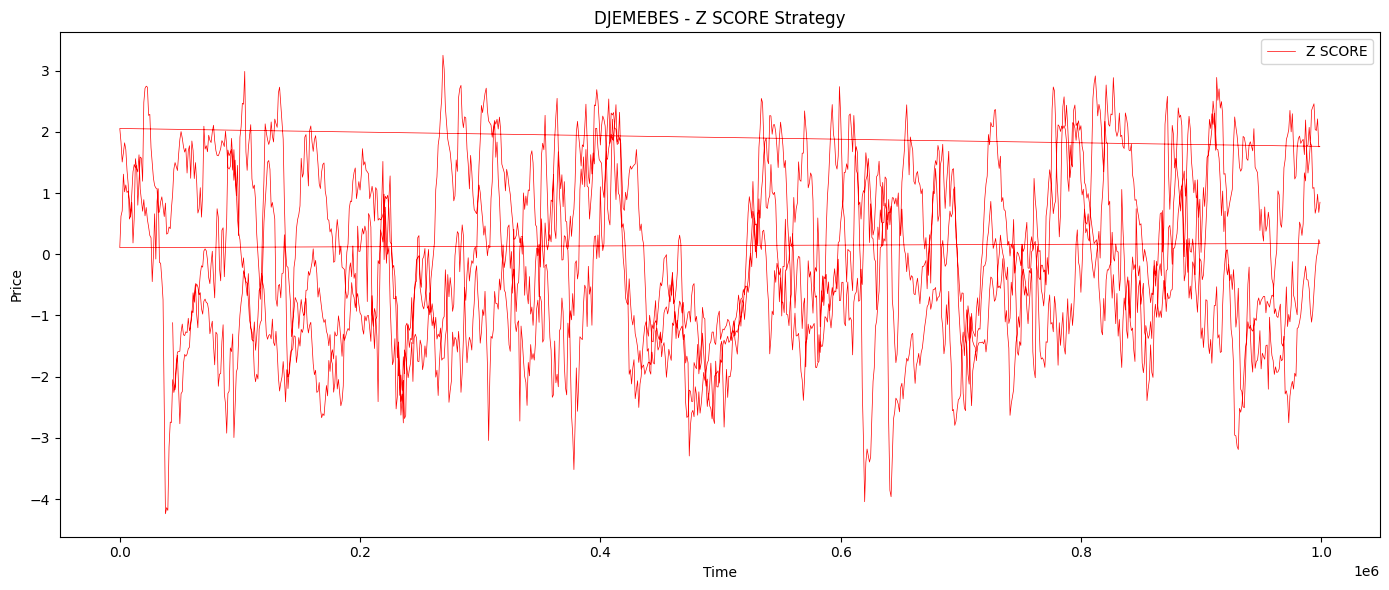

In [28]:
#zscore
window = 45
df_dj.loc[:, 'rolling_mean'] = df_dj['mid_price'].rolling(window = window).mean()
df_dj.loc[:, 'rolling_std'] = df_dj['mid_price'].rolling(window = window).std()
df_dj.loc[:, 'z_score'] =  (df_dj['mid_price'] - df_dj['rolling_mean']) / df_dj['rolling_std']
df_dj.loc[:, 'signal'] = df_dj['z_score'].apply(lambda x: 'Buy' if x<-1 else 'Sell' if x>1 else 'Hold')

plt.figure(figsize=(14, 6))
plt.plot(df_dj['timestamp'], df_dj['z_score'], label='Z SCORE', color = 'red', linewidth = 0.5)
plt.title("DJEMEBES - Z SCORE Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()